In [1]:
import joblib 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [3]:
pca = joblib.load(r'D:\# coding\PYTHON\Society Projects\Team task\pca.pkl')
scaler = joblib.load(r'D:\# coding\PYTHON\Society Projects\Team task\standard_scaler.pkl')
df = joblib.load(r'D:\# coding\PYTHON\Society Projects\Team task\cleaned_dataset.pkl')

In [4]:
x = df.iloc[:,1:33]

In [5]:
x.columns

Index(['python', 'java', 'c_cpp', 'javascript', 'typescript', 'html_css',
       'react', 'angular_vue', 'nodejs', 'fastapi_flask', 'django', 'sql',
       'nosql', 'mongodb', 'postgresql', 'pandas_numpy', 'scikit_learn',
       'deep_learning', 'pytorch_tensorflow', 'nlp', 'computer_vision',
       'docker', 'kubernetes', 'git', 'linux', 'aws', 'azure_gcp', 'ci_cd',
       'terraform', 'cybersecurity_basics', 'penetration_testing',
       'flutter_react_native'],
      dtype='object')

In [7]:
y = df.iloc[:,33]

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [9]:
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [10]:
x_train_pca = pca.transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

In [11]:
x_train_pca.shape

(1119, 29)

In [12]:
lr=LogisticRegression(max_iter=1000)
lr.fit(x_train_pca,y_train)
lr_pred=lr.predict(x_test_pca)

In [13]:
print("Accuracy:",accuracy_score(y_test,lr_pred))
print("Precision:",precision_score(y_test,lr_pred,average="weighted"))
print("Recall:",recall_score(y_test,lr_pred,average="weighted"))
print("F1 Score:",f1_score(y_test,lr_pred,average="weighted"))

Accuracy: 0.85
Precision: 0.8551507051166808
Recall: 0.85
F1 Score: 0.8502514413774396


In [14]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(x_train_pca,y_train)
dt_pred=dt.predict(x_test_pca)

In [15]:
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred, average="weighted"))
print("Recall:", recall_score(y_test, dt_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, dt_pred, average="weighted"))

Accuracy: 0.7714285714285715
Precision: 0.774254624956043
Recall: 0.7714285714285715
F1 Score: 0.7723482743247368


In [16]:
rf=RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_pca,y_train)
rf_pred=rf.predict(x_test_pca)

In [17]:
print("Accuracy:",accuracy_score(y_test,rf_pred))
print("Precision:",precision_score(y_test,rf_pred,average="weighted"))
print("Recall:",recall_score(y_test,rf_pred,average="weighted"))
print("F1 Score:",f1_score(y_test,rf_pred,average="weighted"))

Accuracy: 0.85
Precision: 0.8563881218627764
Recall: 0.85
F1 Score: 0.8495520384792096


In [18]:
models={
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}
for name, pred in models.items():
    print("\n",name)
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred, average="weighted"))
    print("Recall:", recall_score(y_test, pred, average="weighted"))
    print("F1 Score:", f1_score(y_test, pred, average="weighted"))


 Logistic Regression
Accuracy: 0.85
Precision: 0.8551507051166808
Recall: 0.85
F1 Score: 0.8502514413774396

 Decision Tree
Accuracy: 0.7714285714285715
Precision: 0.774254624956043
Recall: 0.7714285714285715
F1 Score: 0.7723482743247368

 Random Forest
Accuracy: 0.85
Precision: 0.8563881218627764
Recall: 0.85
F1 Score: 0.8495520384792096


In [19]:
models={
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

In [20]:
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred, average="weighted"),
        precision_score(y_test, dt_pred, average="weighted"),
        precision_score(y_test, rf_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, lr_pred, average="weighted"),
        recall_score(y_test, dt_pred, average="weighted"),
        recall_score(y_test, rf_pred, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred, average="weighted"),
        f1_score(y_test, dt_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted")
    ]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.850000,0.855151,0.850000,0.850251
1,Decision Tree,0.771429,0.774255,0.771429,0.772348
2,Random Forest,0.850000,0.856388,0.850000,0.849552


In [21]:
best_model = results_df.loc[results_df["F1 Score"].idxmax()]
print(best_model)

Model        Logistic Regression
Accuracy                    0.85
Precision               0.855151
Recall                      0.85
F1 Score                0.850251
Name: 0, dtype: object


In [22]:
import matplotlib.pyplot as plt

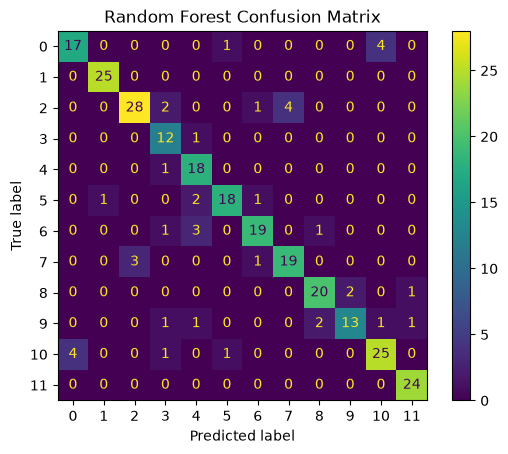

In [23]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

cm=confusion_matrix(y_test,rf_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

### Hyperparameter Tuning


#

In [24]:
from sklearn.model_selection import GridSearchCV

In [25]:
params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [26]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

In [27]:
grid.fit(x_train_pca, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [28]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [29]:
print("Best CV F1 Score:", grid.best_score_)

Best CV F1 Score: 0.8797856135531673


In [30]:
best_rf = grid.best_estimator_

In [31]:
best_rf_pred = best_rf.predict(x_test_pca)

In [32]:
print("Tuned Random Forest")
print("Accuracy:", accuracy_score(y_test, best_rf_pred))
print("Precision:", precision_score(y_test, best_rf_pred, average="weighted"))
print("Recall:", recall_score(y_test, best_rf_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, best_rf_pred, average="weighted"))

Tuned Random Forest
Accuracy: 0.8571428571428571
Precision: 0.863461825377004
Recall: 0.8571428571428571
F1 Score: 0.8568633083325433


In [33]:
print("Original Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred, average="weighted"))

print("\nTuned Random Forest")
print("Accuracy:", accuracy_score(y_test, best_rf_pred))
print("F1 Score:", f1_score(y_test, best_rf_pred, average="weighted"))

Original Random Forest
Accuracy: 0.85
F1 Score: 0.8495520384792096

Tuned Random Forest
Accuracy: 0.8571428571428571
F1 Score: 0.8568633083325433


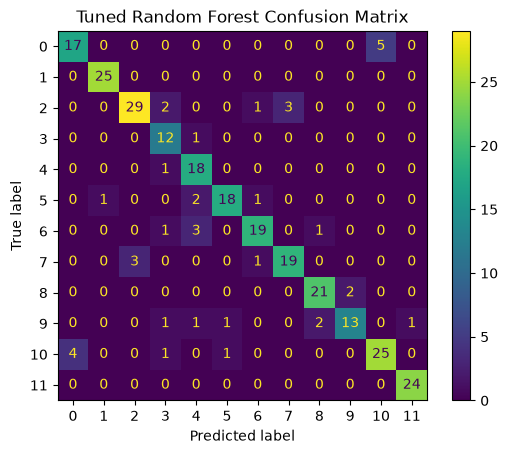

In [34]:
cm = confusion_matrix(y_test, best_rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

In [35]:
from sklearn.metrics import classification_report
print(classification_report(y_test, best_rf_pred))

                           precision    recall  f1-score   support

              AI Engineer       0.81      0.77      0.79        22
        Backend Developer       0.96      1.00      0.98        25
          Cloud Architect       0.91      0.83      0.87        35
    Cybersecurity Analyst       0.67      0.92      0.77        13
             Data Analyst       0.72      0.95      0.82        19
           Data Scientist       0.90      0.82      0.86        22
   Database Administrator       0.86      0.79      0.83        24
          DevOps Engineer       0.86      0.83      0.84        23
       Frontend Developer       0.88      0.91      0.89        23
     Full Stack Developer       0.87      0.68      0.76        19
Machine Learning Engineer       0.83      0.81      0.82        31
     Mobile App Developer       0.96      1.00      0.98        24

                 accuracy                           0.86       280
                macro avg       0.85      0.86      0.85    

In [37]:
joblib.dump(best_rf, r'D:\# coding\PYTHON\Society Projects\Team task\supervised_model.pkl')

['D:\\# coding\\PYTHON\\Society Projects\\Team task\\supervised_model.pkl']

In [39]:
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, best_rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred, average="weighted"),
        precision_score(y_test, dt_pred, average="weighted"),
        precision_score(y_test, rf_pred, average="weighted"),
        precision_score(y_test, best_rf_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, lr_pred, average="weighted"),
        recall_score(y_test, dt_pred, average="weighted"),
        recall_score(y_test, rf_pred, average="weighted"),
        recall_score(y_test, best_rf_pred, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred, average="weighted"),
        f1_score(y_test, dt_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test, best_rf_pred, average="weighted")
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.850000,0.855151,0.850000,0.850251
1,Decision Tree,0.771429,0.774255,0.771429,0.772348
2,Random Forest,0.850000,0.856388,0.850000,0.849552
3,Tuned Random Forest,0.857143,0.863462,0.857143,0.856863


In [40]:
best_model = results_df.loc[results_df["F1 Score"].idxmax()]

print("Best Model:", best_model["Model"])
print("F1 Score:", best_model["F1 Score"])

Best Model: Tuned Random Forest
F1 Score: 0.8568633083325433


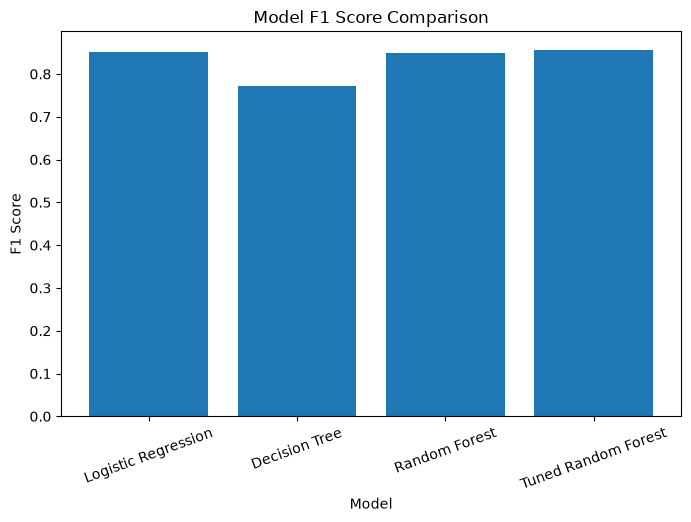

In [41]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Model F1 Score Comparison")
plt.xticks(rotation=20)
plt.show()

In [42]:
print(classification_report(y_test, best_rf_pred))

                           precision    recall  f1-score   support

              AI Engineer       0.81      0.77      0.79        22
        Backend Developer       0.96      1.00      0.98        25
          Cloud Architect       0.91      0.83      0.87        35
    Cybersecurity Analyst       0.67      0.92      0.77        13
             Data Analyst       0.72      0.95      0.82        19
           Data Scientist       0.90      0.82      0.86        22
   Database Administrator       0.86      0.79      0.83        24
          DevOps Engineer       0.86      0.83      0.84        23
       Frontend Developer       0.88      0.91      0.89        23
     Full Stack Developer       0.87      0.68      0.76        19
Machine Learning Engineer       0.83      0.81      0.82        31
     Mobile App Developer       0.96      1.00      0.98        24

                 accuracy                           0.86       280
                macro avg       0.85      0.86      0.85    

In [44]:
loaded_model = joblib.load(r'D:\# coding\PYTHON\Society Projects\Team task\supervised_model.pkl')
test_prediction = loaded_model.predict(x_test_pca[:5])
print(test_prediction)

['Data Analyst' 'Cloud Architect' 'DevOps Engineer'
 'Machine Learning Engineer' 'Cloud Architect']


In [46]:
sample = x_test.iloc[:5]

In [47]:
sample_scaled = scaler.transform(sample)

In [48]:
sample_pca = pca.transform(sample_scaled)

In [49]:
sample_prediction = best_rf.predict(sample_pca)
print(sample_prediction)

['Data Analyst' 'Cloud Architect' 'DevOps Engineer'
 'Machine Learning Engineer' 'Cloud Architect']
